# Model Building
Purpose: Train an ANN model on the cleaned data, model performance evaluation and visual analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

## Loading Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned_telco.csv')
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Building Neural Network

In [3]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(26, activation='relu'),
    Dense(13, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Training Model

In [4]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - accuracy: 0.6844 - loss: 0.5701
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - accuracy: 0.7936 - loss: 0.4348
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.7968 - loss: 0.4230
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - accuracy: 0.8025 - loss: 0.4163
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8037 - loss: 0.4143
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.8046 - loss: 0.4108
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.8066 - loss: 0.4099
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8068 - loss: 0.4084
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.8075 - loss: 0.4069
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.8091 - loss: 0.4067
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.8121 - loss: 0.4042
Epoch 12/100
176/17

## Model Evaluation

### Classification Report

In [5]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1033
           1       0.55      0.52      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.75      1407



### Confusion Matrix

Text(45.722222222222214, 0.5, 'True')

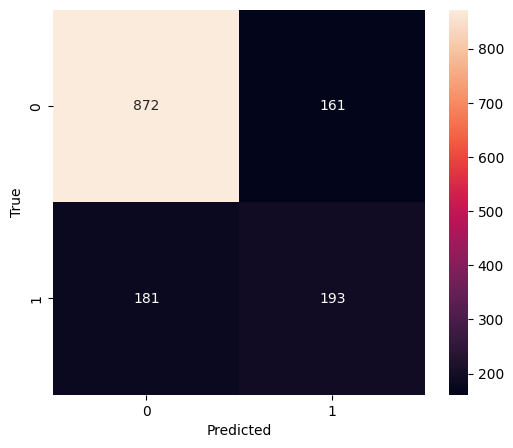

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')

## Saving The Model

In [7]:
model.save("../models/final_model.keras")